<a href="https://colab.research.google.com/github/vaidegiarch/project-2-/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Collection

In [ ]:
import pandas as pd

df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [ ]:
import pandas as pd

df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_youth.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [ ]:
import pandas as pd

df_illiterate = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_illiterate.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [ ]:
import pandas as pd

df_gdp = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [ ]:
import pandas as pd

df_school = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_school.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


merge into 3 df





### df_literacy → Adult & Youth Literacy Rates




In [ ]:
df_literacy = pd.merge(df_adult, df_youth,
                       on=["entity", "year"],
                       how="inner")       #df_literacy (Adult + Youth)

df_literacy.head()

,entity,code_x,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,code_y,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,18.00000,AFG,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,AFG,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,AFG,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,AFG,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,ALB,99.00000,99.00000,Europe


In [ ]:
df_literacy.isnull().sum()#locating null value

,0
entity,0
code_x,729
year,0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,0
code_y,729
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,0
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,0
owid_region,777


In [ ]:
df_literacy_sorted=df_literacy.drop(['code_x', 'code_y','owid_region'], axis=1)#dropped column that has null val

In [ ]:
df_literacy_sorted.rename(columns={'entity': 'country',
                              'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99': 'adult_literacy',
                              'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m': 'male_youth_literacy',
                              'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f':'female_youth_literacy',
                              }, inplace=True)#renaming column name

In [ ]:
df_literacy_sorted

,country,year,adult_literacy,male_youth_literacy,female_youth_literacy
0,Afghanistan,1979,18.00000,46.00000,11.00000
1,Afghanistan,2011,31.00000,62.00000,32.00000
2,Afghanistan,2015,33.75384,57.73505,25.48416
3,Afghanistan,2021,37.00000,71.00000,42.00000
4,Albania,2001,99.00000,99.00000,99.00000
...,...,...,...,...,...
1703,Zambia,2010,83.00000,91.00000,87.00000
1704,Zambia,2018,71.13230,82.44786,72.90992
1705,Zimbabwe,1982,78.00000,94.00000,85.00000
1706,Zimbabwe,1992,84.00000,97.00000,94.00000


In [ ]:
df_literacy_final=df_literacy_sorted[
    (df_literacy_sorted["year"] >= 1990) &
    (df_literacy_sorted["year"] <= 2023)
]
df_literacy_final

,country,year,adult_literacy,male_youth_literacy,female_youth_literacy
1,Afghanistan,2011,31.00000,62.00000,32.00000
2,Afghanistan,2015,33.75384,57.73505,25.48416
3,Afghanistan,2021,37.00000,71.00000,42.00000
4,Albania,2001,99.00000,99.00000,99.00000
5,Albania,2008,96.00000,99.00000,99.00000
...,...,...,...,...,...
1702,Zambia,2002,69.00000,78.00000,66.00000
1703,Zambia,2010,83.00000,91.00000,87.00000
1704,Zambia,2018,71.13230,82.44786,72.90992
1706,Zimbabwe,1992,84.00000,97.00000,94.00000


In [ ]:
# Sort the DataFrame by the 'Year' column in ascending order
df_literacy_final.sort_values(by='year', ascending=True)
df_literacy_final

,country,year,adult_literacy,male_youth_literacy,female_youth_literacy
1,Afghanistan,2011,31.00000,62.00000,32.00000
2,Afghanistan,2015,33.75384,57.73505,25.48416
3,Afghanistan,2021,37.00000,71.00000,42.00000
4,Albania,2001,99.00000,99.00000,99.00000
5,Albania,2008,96.00000,99.00000,99.00000
...,...,...,...,...,...
1702,Zambia,2002,69.00000,78.00000,66.00000
1703,Zambia,2010,83.00000,91.00000,87.00000
1704,Zambia,2018,71.13230,82.44786,72.90992
1706,Zimbabwe,1992,84.00000,97.00000,94.00000


### df_literacy_final-1 data frame

In [ ]:
df_literacy_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1405 entries, 1 to 1707
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1405 non-null   object 
 1   year                   1405 non-null   int64  
 2   adult_literacy         1405 non-null   float64
 3   male_youth_literacy    1405 non-null   float64
 4   female_youth_literacy  1405 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 65.9+ KB


### df_illiteracy → Illiterate Population Data

In [ ]:
df_illiterate.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [ ]:
df_illiterate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   entity           2059 non-null   object 
 1   code             1326 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy_rate  2059 non-null   float64
 4   literacy_rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.6+ KB


In [ ]:
df_illiterate.isnull().sum()#locating null value

,0
entity,0
code,733
year,0
illiteracy_rate,0
literacy_rate,0


In [ ]:
df_illiterate_1=df_illiterate.drop('code', axis=1)#dropped column that has null val

In [ ]:
#  rename colmn name
df_illiterate_1.rename(columns={'entity':'country'})

,country,year,illiteracy_rate,literacy_rate
0,Afghanistan,1950,97.000000,3.00000
1,Afghanistan,1979,82.000000,18.00000
2,Afghanistan,2011,69.000000,31.00000
3,Afghanistan,2015,66.246155,33.75384
4,Afghanistan,2021,63.000000,37.00000
...,...,...,...,...
2054,Zanzibar,1950,92.500000,7.50000
2055,Zimbabwe,1950,77.500000,22.50000
2056,Zimbabwe,1982,22.000000,78.00000
2057,Zimbabwe,1992,16.000000,84.00000


In [ ]:
df_illiterate_final1=df_illiterate_final[
    (df_illiterate_final["year"] >= 1990) &
    (df_illiterate_final["year"] <= 2023)
]
df_illiterate_final1

,country,year,illiteracy_rate,literacy_rate
2,Afghanistan,2011,69.000000,31.00000
3,Afghanistan,2015,66.246155,33.75384
4,Afghanistan,2021,63.000000,37.00000
6,Albania,2001,1.000000,99.00000
7,Albania,2008,4.000000,96.00000
...,...,...,...,...
2051,Zambia,2002,31.000000,69.00000
2052,Zambia,2010,17.000000,83.00000
2053,Zambia,2018,28.867699,71.13230
2057,Zimbabwe,1992,16.000000,84.00000


In [ ]:
df_illiterate_final1

,country,year,illiteracy_rate,literacy_rate
2,Afghanistan,2011,69.000000,31.00000
3,Afghanistan,2015,66.246155,33.75384
4,Afghanistan,2021,63.000000,37.00000
6,Albania,2001,1.000000,99.00000
7,Albania,2008,4.000000,96.00000
...,...,...,...,...
2051,Zambia,2002,31.000000,69.00000
2052,Zambia,2010,17.000000,83.00000
2053,Zambia,2018,28.867699,71.13230
2057,Zimbabwe,1992,16.000000,84.00000


### df_illiterate_final1- 2 data frame

## df_gdp_schooling → GDP & Years of Schooling

In [ ]:
df_gdp_schooling=pd.merge(df_school, df_gdp,
                       on=["entity", "year"],
                       how="inner")       #df_literacy (GDP + SCHOOL)

df_gdp_schooling.head()

,entity,code_x,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region_x,code_y,ny_gdp_pcap_pp_kd,owid_region_y
0,Afghanistan,AFG,2000,NaN,3.03,20130334.0,Asia,AFG,1617.8264,Asia
1,Afghanistan,AFG,2005,NaN,3.32,24404575.0,Asia,AFG,1908.1147,Asia
2,Afghanistan,AFG,2010,NaN,3.93,28284088.0,Asia,AFG,2848.5862,Asia
3,Afghanistan,AFG,2011,31.00000,NaN,29347708.0,Asia,AFG,2757.0525,Asia
4,Afghanistan,AFG,2015,33.75384,4.81,33831767.0,Asia,AFG,2967.6921,Asia


In [ ]:
df_gdp_schooling.isnull().sum()#locating null value

,0
entity,0
code_x,280
year,0
literacy_rate,678
mf_youth_and_adults__15_64_years__average_years_of_education,963
population_historical,178
owid_region_x,280
code_y,0
ny_gdp_pcap_pp_kd,0
owid_region_y,280


In [ ]:
df_gdp_schooling_final=df_gdp_schooling.drop(['owid_region_x', 'code_x','owid_region_x','owid_region_y','code_y','literacy_rate'], axis=1)#dropped column that has null val

In [ ]:
df_gdp_schooling_final

,entity,year,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,ny_gdp_pcap_pp_kd
0,Afghanistan,2000,3.03,20130334.0,1617.8264
1,Afghanistan,2005,3.32,24404575.0,1908.1147
2,Afghanistan,2010,3.93,28284088.0,2848.5862
3,Afghanistan,2011,NaN,29347708.0,2757.0525
4,Afghanistan,2015,4.81,33831767.0,2967.6921
...,...,...,...,...,...
1767,Zimbabwe,2005,7.65,12483433.0,4004.6646
1768,Zimbabwe,2010,7.86,13356551.0,3885.3938
1769,Zimbabwe,2015,8.03,14399008.0,5102.7144
1770,Zimbabwe,2019,NaN,15271377.0,4993.8438


In [ ]:
df_gdp_schooling_final.rename(columns={'entity': 'country',
                              'mf_youth_and_adults__15_64_years__average_years_of_education': 'avg_years_of_schooling',
                              'population_historical': 'population',
                              'ny_gdp_pcap_pp_kd':'GDP_per_capita_PPP',
                              }, inplace=True)#renaming column name

In [ ]:
df_gdp_schooling_final

,country,year,avg_years_of_schooling,population,GDP_per_capita_PPP
0,Afghanistan,2000,3.03,20130334.0,1617.8264
1,Afghanistan,2005,3.32,24404575.0,1908.1147
2,Afghanistan,2010,3.93,28284088.0,2848.5862
3,Afghanistan,2011,NaN,29347708.0,2757.0525
4,Afghanistan,2015,4.81,33831767.0,2967.6921
...,...,...,...,...,...
1767,Zimbabwe,2005,7.65,12483433.0,4004.6646
1768,Zimbabwe,2010,7.86,13356551.0,3885.3938
1769,Zimbabwe,2015,8.03,14399008.0,5102.7144
1770,Zimbabwe,2019,NaN,15271377.0,4993.8438


In [ ]:
df_gdp_schooling_final[
    (df_gdp_schooling_final["year"] >= 1990) &
    (df_gdp_schooling_final["year"] <= 2023)
]





,country,year,avg_years_of_schooling,population,GDP_per_capita_PPP
0,Afghanistan,2000,3.03,20130334.0,1617.8264
1,Afghanistan,2005,3.32,24404575.0,1908.1147
2,Afghanistan,2010,3.93,28284088.0,2848.5862
3,Afghanistan,2011,NaN,29347708.0,2757.0525
4,Afghanistan,2015,4.81,33831767.0,2967.6921
...,...,...,...,...,...
1767,Zimbabwe,2005,7.65,12483433.0,4004.6646
1768,Zimbabwe,2010,7.86,13356551.0,3885.3938
1769,Zimbabwe,2015,8.03,14399008.0,5102.7144
1770,Zimbabwe,2019,NaN,15271377.0,4993.8438


# 1.df_literacy_final
# 2.df_illiterate_final1
# 3.df_gdp_schooling_final

### Feature Engineering
Creating new columns can help uncover deeper insights from the data


In [ ]:
df_illiterate_final1.loc[:, "Illiteracy_%"] = 100 - df_illiterate_final["literacy_rate"]
df_illiterate_final1
#Illiteracy %=already have literacy rate, illiteracy is just 100 − literacy.

,country,year,illiteracy_rate,literacy_rate,Illiteracy_percent,Illiteracy_%
2,Afghanistan,2011,69.000000,31.00000,69.00000,69.00000
3,Afghanistan,2015,66.246155,33.75384,66.24616,66.24616
4,Afghanistan,2021,63.000000,37.00000,63.00000,63.00000
6,Albania,2001,1.000000,99.00000,1.00000,1.00000
7,Albania,2008,4.000000,96.00000,4.00000,4.00000
...,...,...,...,...,...,...
2051,Zambia,2002,31.000000,69.00000,31.00000,31.00000
2052,Zambia,2010,17.000000,83.00000,17.00000,17.00000
2053,Zambia,2018,28.867699,71.13230,28.86770,28.86770
2057,Zimbabwe,1992,16.000000,84.00000,16.00000,16.00000


In [ ]:
df_illiterate_final1 = df_illiterate_final1.rename(columns={'Illiteracy_%':'Illiteracy_percent'})

In [ ]:
df_literacy_final.loc[:,"Literacy_Gender_Gap"] = abs(df_literacy_final["male_youth_literacy"] - df_literacy_final["female_youth_literacy"])
df_literacy_final#Literacy Gender Gap- absolute value (Highlights the disparity between male and female literacy rates.)

,country,year,adult_literacy,male_youth_literacy,female_youth_literacy,Literacy_Gender_Gap,Youth_Literacy_Avg,Literacy_Growth_Rate
1,Afghanistan,2011,31.00000,62.00000,32.00000,30.00000,47.000000,NaN
2,Afghanistan,2015,33.75384,57.73505,25.48416,32.25089,41.609605,8.883355
3,Afghanistan,2021,37.00000,71.00000,42.00000,29.00000,56.500000,9.617158
4,Albania,2001,99.00000,99.00000,99.00000,0.00000,99.000000,NaN
5,Albania,2008,96.00000,99.00000,99.00000,0.00000,99.000000,-3.030303
...,...,...,...,...,...,...,...,...
1702,Zambia,2002,69.00000,78.00000,66.00000,12.00000,72.000000,1.470588
1703,Zambia,2010,83.00000,91.00000,87.00000,4.00000,89.000000,20.289855
1704,Zambia,2018,71.13230,82.44786,72.90992,9.53794,77.678890,-14.298434
1706,Zimbabwe,1992,84.00000,97.00000,94.00000,3.00000,95.500000,NaN


In [ ]:
df_gdp_schooling_final["GDP_per_Schooling_Year"] = df_gdp_schooling_final["GDP_per_capita_PPP"] / df_gdp_schooling_final["avg_years_of_schooling"]
df_gdp_schooling_final #GDP per Schooling Year=GDP per capita and average schooling years(div)

,country,year,avg_years_of_schooling,population,GDP_per_capita_PPP,GDP_per_Schooling_Year,Education_Index
0,Afghanistan,2000,3.03,20130334.0,1617.8264,533.936106,0.220524
1,Afghanistan,2005,3.32,24404575.0,1908.1147,574.733343,0.241630
2,Afghanistan,2010,3.93,28284088.0,2848.5862,724.831094,0.286026
3,Afghanistan,2011,NaN,29347708.0,2757.0525,NaN,NaN
4,Afghanistan,2015,4.81,33831767.0,2967.6921,616.983805,0.350073
...,...,...,...,...,...,...,...
1767,Zimbabwe,2005,7.65,12483433.0,4004.6646,523.485569,0.556769
1768,Zimbabwe,2010,7.86,13356551.0,3885.3938,494.324911,0.572052
1769,Zimbabwe,2015,8.03,14399008.0,5102.7144,635.456339,0.584425
1770,Zimbabwe,2019,NaN,15271377.0,4993.8438,NaN,NaN


In [ ]:
df_gdp_schooling_final["Education_Index"] = df_gdp_schooling_final["avg_years_of_schooling"] / df_gdp_schooling_final["avg_years_of_schooling"].max()
df_gdp_schooling_final#Education Index Measures education quality by considering both access (literacy) and duration (schooling).

,country,year,avg_years_of_schooling,population,GDP_per_capita_PPP,GDP_per_Schooling_Year,Education_Index
0,Afghanistan,2000,3.03,20130334.0,1617.8264,533.936106,0.220524
1,Afghanistan,2005,3.32,24404575.0,1908.1147,574.733343,0.241630
2,Afghanistan,2010,3.93,28284088.0,2848.5862,724.831094,0.286026
3,Afghanistan,2011,NaN,29347708.0,2757.0525,NaN,NaN
4,Afghanistan,2015,4.81,33831767.0,2967.6921,616.983805,0.350073
...,...,...,...,...,...,...,...
1767,Zimbabwe,2005,7.65,12483433.0,4004.6646,523.485569,0.556769
1768,Zimbabwe,2010,7.86,13356551.0,3885.3938,494.324911,0.572052
1769,Zimbabwe,2015,8.03,14399008.0,5102.7144,635.456339,0.584425
1770,Zimbabwe,2019,NaN,15271377.0,4993.8438,NaN,NaN


In [ ]:
df_literacy_final.loc[:,"Youth_Literacy_Avg"] = (
    df_literacy_final["male_youth_literacy"] + df_literacy_final["female_youth_literacy"]
) / 2
df_literacy_final#Youth Literacy Average
#Provides a single indicator for overall youth literacy.




,country,year,adult_literacy,male_youth_literacy,female_youth_literacy,Literacy_Gender_Gap,Youth_Literacy_Avg,Literacy_Growth_Rate
1,Afghanistan,2011,31.00000,62.00000,32.00000,30.00000,47.000000,NaN
2,Afghanistan,2015,33.75384,57.73505,25.48416,32.25089,41.609605,8.883355
3,Afghanistan,2021,37.00000,71.00000,42.00000,29.00000,56.500000,9.617158
4,Albania,2001,99.00000,99.00000,99.00000,0.00000,99.000000,NaN
5,Albania,2008,96.00000,99.00000,99.00000,0.00000,99.000000,-3.030303
...,...,...,...,...,...,...,...,...
1702,Zambia,2002,69.00000,78.00000,66.00000,12.00000,72.000000,1.470588
1703,Zambia,2010,83.00000,91.00000,87.00000,4.00000,89.000000,20.289855
1704,Zambia,2018,71.13230,82.44786,72.90992,9.53794,77.678890,-14.298434
1706,Zimbabwe,1992,84.00000,97.00000,94.00000,3.00000,95.500000,NaN


In [ ]:
df_literacy_final.loc[:,"Literacy_Growth_Rate"] = df_literacy_final.groupby("country")["adult_literacy"].pct_change() * 100
df_literacy_final#how much literacy improved from one year to the next.
#Literacy Growth Rate ,.pct_change()-percentage change between consecutive rows.

,country,year,adult_literacy,male_youth_literacy,female_youth_literacy,Literacy_Gender_Gap,Youth_Literacy_Avg,Literacy_Growth_Rate
1,Afghanistan,2011,31.00000,62.00000,32.00000,30.00000,47.000000,NaN
2,Afghanistan,2015,33.75384,57.73505,25.48416,32.25089,41.609605,8.883355
3,Afghanistan,2021,37.00000,71.00000,42.00000,29.00000,56.500000,9.617158
4,Albania,2001,99.00000,99.00000,99.00000,0.00000,99.000000,NaN
5,Albania,2008,96.00000,99.00000,99.00000,0.00000,99.000000,-3.030303
...,...,...,...,...,...,...,...,...
1702,Zambia,2002,69.00000,78.00000,66.00000,12.00000,72.000000,1.470588
1703,Zambia,2010,83.00000,91.00000,87.00000,4.00000,89.000000,20.289855
1704,Zambia,2018,71.13230,82.44786,72.90992,9.53794,77.678890,-14.298434
1706,Zimbabwe,1992,84.00000,97.00000,94.00000,3.00000,95.500000,NaN


Exploratory Data Analysis (EDA) using visualization libraries like Matplotlib, Seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Univariate Analysis for each data set

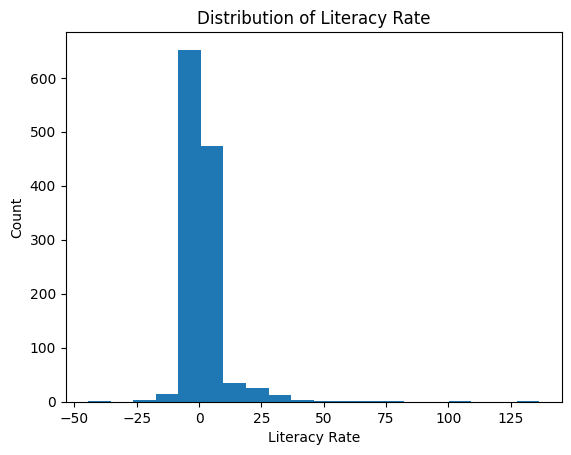

In [ ]:
plt.hist(df_literacy_final["Literacy_Growth_Rate"], bins=20)
plt.title("Distribution of Literacy Rate")
plt.xlabel("Literacy Rate")
plt.ylabel("Count")
plt.show()#Literacy Rate Distribution (Histogram)

insights-
The distribution is highly peaked around zero with a slight right skew, but the presence of impossible values (below 0 and above 100%) suggests significant data quality issues or a miscalculation in the literacy rate variable.

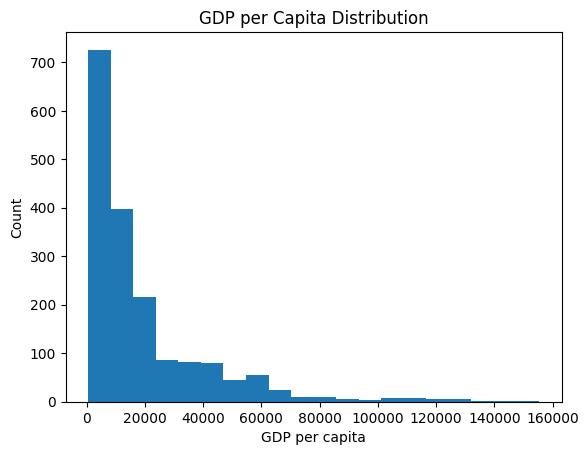

In [ ]:
plt.hist(df_gdp_schooling_final["GDP_per_capita_PPP"], bins=20)
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per capita")
plt.ylabel("Count")
plt.show()#GDP Distribution

insights-
The histogram reveals a highly right-skewed distribution, where the vast majority of the population earns below $20,000, with a long "thin tail" of high-income outliers stretching toward $160,000

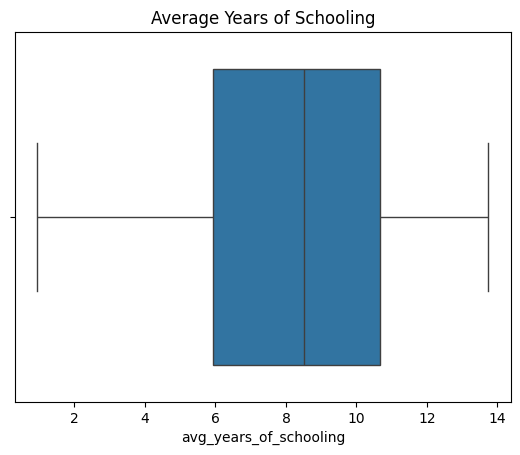

In [ ]:
sns.boxplot(x=df_gdp_schooling_final["avg_years_of_schooling"])
plt.title("Average Years of Schooling")
plt.show()#Schooling Years (Box Plot)

insights-

The boxplot shows a median of roughly 8.5 years of schooling, with the middle 50% of the population (IQR) falling between 6 and 11 years, indicating a relatively broad but balanced distribution without any visible outliers.

### Bivariate Analysis- between two variables

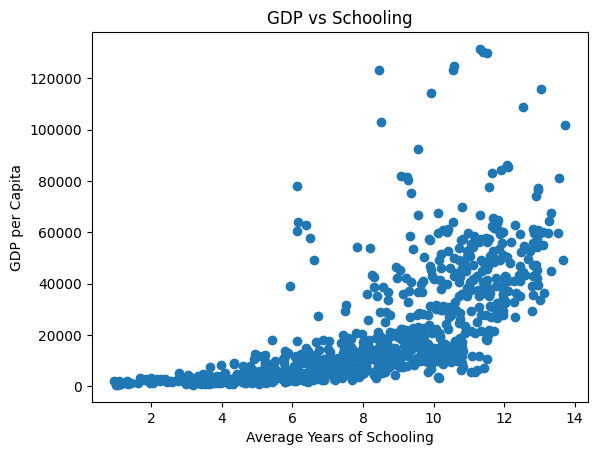

In [ ]:
#GDP vs Schooling
plt.scatter(df_gdp_schooling_final["avg_years_of_schooling"],
            df_gdp_schooling_final["GDP_per_capita_PPP"])

plt.xlabel("Average Years of Schooling")
plt.ylabel("GDP per Capita")
plt.title("GDP vs Schooling")
plt.show()

insights-average years of schooling are strongly associated with increased GDP per capita, illustrating a nonlinear "tipping point" around 8 years where economic output begins to accelerate significantly.

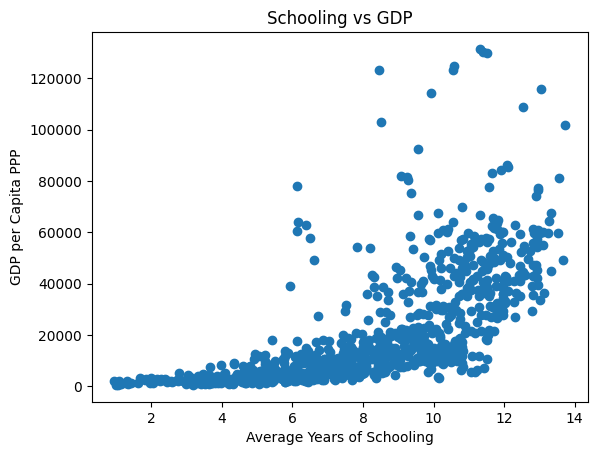

In [ ]:
#schooling vs GDP
plt.scatter(df_gdp_schooling_final["avg_years_of_schooling"],
            df_gdp_schooling_final["GDP_per_capita_PPP"])

plt.xlabel("Average Years of Schooling")
plt.ylabel("GDP per Capita PPP")
plt.title("Schooling vs GDP")
plt.show()

insights-
The scatter plot reveals an exponential relationship where GDP per capita remains low until approximately 8 years of schooling, after which it begins to rise sharply, though with significantly higher variance among advanced economies.

### Correlation Heatmap

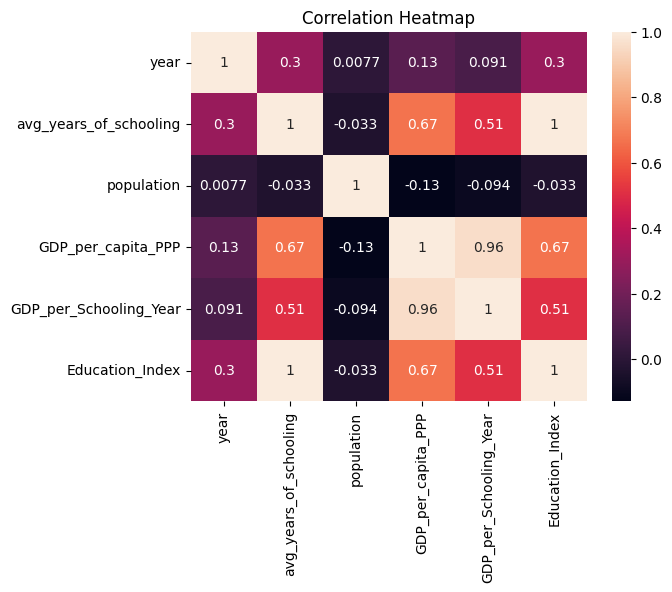

In [ ]:
numeric_df = df_gdp_schooling_final.select_dtypes(include='number')

corr = numeric_df.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

insights-

There is a strong positive correlation between education and wealth, with Education_Index and avg_years_of_schooling showing a high relationship to GDP_per_capita_PPP (0.67), while population size appears to have almost no influence on these metrics.

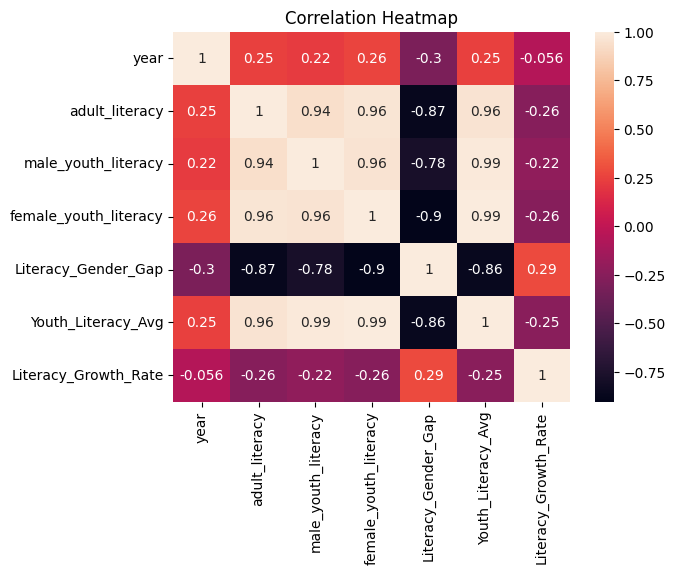

In [ ]:
numeric_df = df_literacy_final.select_dtypes(include='number')

corr = numeric_df.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

insights-Literacy metrics are near-perfectly positively correlated with each other ($0.94$ to $0.99$), while showing a strong negative correlation with the Gender Gap (up to $-0.90$), indicating that as overall literacy rises, the disparity between genders significantly decreases.

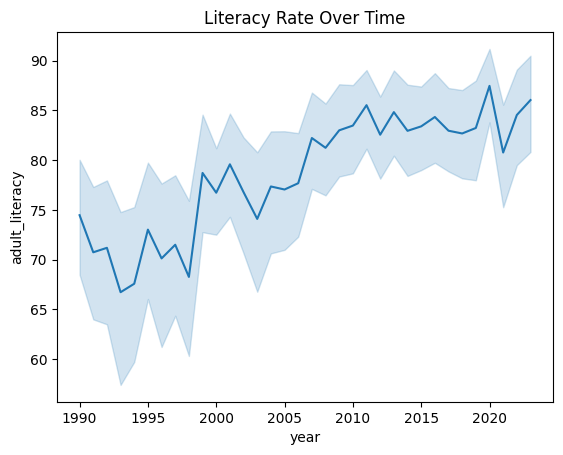

In [ ]:
sns.lineplot(x="year", y="adult_literacy", data=df_literacy_final)
plt.title("Literacy Rate Over Time")
plt.show()

insights-

Global adult literacy shows a steady upward trend from 1990 to 2023, rising from roughly 74% to 86%, though the narrowing shaded area suggests a decrease in the data's variance over time.

sql queries

In [ ]:
pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
import sqlite3
conn = sqlite3.connect("df_literacy_final.db")
cursor = conn.cursor()
print("SQLite connected")

SQLite connected


In [ ]:
# Pushing dataframe into sql

df_literacy_final.to_sql(" literacy_rates", conn, if_exists="replace", index=False)

1405

In [ ]:
print(df_literacy_final.columns)

Index(['country', 'year', 'adult_literacy', 'male_youth_literacy',
       'female_youth_literacy', 'Literacy_Gender_Gap', 'Youth_Literacy_Avg',
       'Literacy_Growth_Rate'],
      dtype='object')


In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS literacy_rates (
    country TEXT,
    year INTEGER,
    adult_literacy FLOAT,
    male_youth_literacy FLOAT,
    female_youth_literacy FLOAT,
    Literacy_Gender_Gap FLOAT,
    Youth_Literacy_Avg FLOAT,
    Literacy_Growth_Rate FLOAT
    );
""")

In [ ]:
sql = """
INSERT INTO literacy_rates
(country, year, adult_literacy, male_youth_literacy, female_youth_literacy,
Literacy_Gender_Gap, Youth_Literacy_Avg, Literacy_Growth_Rate)

VALUES
(?, ?, ?, ?, ?, ?, ?, ? )"""

In [ ]:
data = df_literacy_final[['country', 'year', 'adult_literacy', 'male_youth_literacy',
       'female_youth_literacy', 'Literacy_Gender_Gap', 'Youth_Literacy_Avg',
       'Literacy_Growth_Rate']].values.tolist()

In [ ]:
cursor.executemany(sql, data)
conn.commit()


In [ ]:
cursor.execute("""SELECT country, adult_literacy
FROM literacy_rates
WHERE year = 2020
ORDER BY adult_literacy DESC
LIMIT 5;
""")

rows = cursor.fetchall()#Get top 5 countries with highest adult literacy in 2020.

for row in rows:
    print(row)

('Armenia', 100.0)
('Armenia', 100.0)
('Mongolia', 99.0)
('Spain', 99.0)
('Mongolia', 99.0)


In [ ]:
cursor.execute("""SELECT country, year, female_youth_literacy
FROM literacy_rates
WHERE female_youth_literacy < 80;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)  #Find countries where female youth literacy < 80%.

('Afghanistan', 2011, 32.0)
('Afghanistan', 2015, 25.48416)
('Afghanistan', 2021, 42.0)
('Angola', 2001, 63.0)
('Angola', 2014, 71.0)
('Angola', 2015, 67.4276)
('Bangladesh', 1991, 38.0)
('Bangladesh', 2001, 60.0)
('Bangladesh', 2012, 79.0)
('Belize', 1991, 78.0)
('Benin', 1992, 27.0)
('Benin', 2002, 33.0)
('Benin', 2017, 50.98536)
('Benin', 2019, 62.76271)
('Benin', 2021, 59.18644)
('Benin', 2022, 67.93813)
('Bhutan', 2005, 68.0)
('Burkina Faso', 1991, 14.0)
('Burkina Faso', 1996, 14.0)
('Burkina Faso', 2003, 25.0)
('Burkina Faso', 2005, 26.0)
('Burkina Faso', 2006, 27.0)
('Burkina Faso', 2007, 33.0)
('Burkina Faso', 2014, 44.0)
('Burkina Faso', 2018, 54.0)
('Burkina Faso', 2019, 44.0)
('Burkina Faso', 2021, 58.758)
('Burkina Faso', 2022, 60.56925)
('Burundi', 1990, 48.0)
('Burundi', 2000, 70.0)
('Burundi', 2008, 57.0)
('Burundi', 2014, 75.0)
('Cambodia', 1998, 71.0)
('Cambodia', 2004, 79.0)
('Cameroon', 2000, 78.0)
('Cameroon', 2007, 77.0)
('Cameroon', 2010, 76.0)
('Cameroon', 2018, 

In [ ]:
cursor.execute("""SELECT country,
                  AVG(adult_literacy) AS avg_adult_literacy
                  FROM literacy_rates
                  GROUP BY country
                  ORDER BY avg_adult_literacy DESC;
""")

rows = cursor.fetchall()#Average adult literacy per  (country).

for row in rows:
    print(row)

('Slovenia', 100.0)
('San Marino', 100.0)
('North Korea', 100.0)
('Lithuania', 100.0)
('Latvia', 100.0)
('Kazakhstan', 100.0)
('Estonia', 100.0)
('Belarus', 100.0)
('Azerbaijan', 99.92307692307692)
('Uzbekistan', 99.88888888888889)
('Armenia', 99.80416666666667)
('Georgia', 99.70152166666666)
('Russia', 99.66666666666667)
('Cuba', 99.21830333333332)
('Ukraine', 99.0)
('Turkmenistan', 99.0)
('Tajikistan', 99.0)
('Kyrgyzstan', 99.0)
('Guam', 99.0)
('Cayman Islands', 99.0)
('North America (WB)', 98.70909333333334)
('Italy', 98.66666666666667)
('Palau', 98.5)
('Samoa', 98.49756500000001)
('Europe and Northern America (SDG)', 98.36298222222223)
('Uruguay', 98.3125)
('Mongolia', 98.124514)
('Spain', 98.0)
('South Korea', 98.0)
('Serbia', 98.0)
('Romania', 98.0)
('Moldova', 98.0)
('Marshall Islands', 98.0)
('Bulgaria', 98.0)
('Kiribati', 97.95971)
('Albania', 97.563246)
('Europe and Central Asia (WB)', 97.54337566666669)
('Croatia', 97.5)
('Tonga', 97.010324)
('Trinidad and Tobago', 97.0)
('S

In [ ]:
import sqlite3
conn = sqlite3.connect("df_illiterate_final1.db")
cursor = conn.cursor()
print("SQLite connected")

SQLite connected


In [ ]:
# This keeps the first occurrence and removes subsequent duplicates
df_illiterate_final1 = df_illiterate_final1.loc[:, ~df_illiterate_final1.columns.duplicated()]

In [ ]:
# Pushing dataframe into sql

df_illiterate_final1.to_sql("illiteracy_population", conn, if_exists="replace", index=False)

1419

In [ ]:
print(df_illiterate_final1.columns)

Index(['country', 'year', 'illiteracy_rate', 'literacy_rate',
       'Illiteracy_percent'],
      dtype='object')


In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS illiteracy_population (
    country TEXT,
    year INTEGER,
    illiteracy_rate FLOAT,
    literacy_rate FLOAT,
    Illiteracy_percent FLOAT
);
""")

In [ ]:
sql = """
INSERT INTO illiteracy_population
(country,year,illiteracy_rate,literacy_rate ,Illiteracy_percent
)

VALUES
(?, ?, ?, ?, ? )"""

In [ ]:
data = df_illiterate_final1[['country', 'year', 'illiteracy_rate', 'literacy_rate', 'Illiteracy_percent']].values.tolist()

In [ ]:
cursor.executemany(sql, data)
conn.commit()

In [ ]:
cursor.execute("""SELECT  country, year, Illiteracy_percent
FROM illiteracy_population
WHERE year = 2000
AND Illiteracy_percent > 20;
""")

rows = cursor.fetchall()#Countries with illiteracy % > 20% in 2000.

for row in rows:
    print(row)

('Burundi', 2000, 41.0)
('Cameroon', 2000, 32.0)
('Central African Republic', 2000, 49.0)
('Central and Southern Asia (SDG)', 2000, 39.91697)
('Chad', 2000, 74.0)
('Comoros', 2000, 32.0)
("Cote d'Ivoire", 2000, 51.0)
('Gambia', 2000, 63.0)
('Ghana', 2000, 42.0)
('Guinea-Bissau', 2000, 59.0)
('Iraq', 2000, 26.0)
('Laos', 2000, 30.0)
('Low-income countries', 2000, 48.60134)
('Lower-middle-income countries', 2000, 37.19769)
('Madagascar', 2000, 29.0)
('Mauritania', 2000, 49.0)
('Middle East and North Africa (WB)', 2000, 30.59841)
('Middle-income countries', 2000, 21.022769999999994)
('Northern Africa and Western Asia (SDG)', 2000, 27.835139999999996)
('Oceania (excluding Australia and New Zealand) (SDG)', 2000, 34.64868)
('Papua New Guinea', 2000, 43.0)
('Rwanda', 2000, 35.0)
('Saudi Arabia', 2000, 21.0)
('South Asia (WB)', 2000, 42.34942)
('Sub-Saharan Africa (SDG)', 2000, 43.6094)
('Sub-Saharan Africa (WB)', 2000, 43.37245)
('Sudan', 2000, 39.0)
('Togo', 2000, 47.0)
('Burundi', 2000, 41

In [ ]:
cursor.execute("""SELECT year, Illiteracy_percent
FROM illiteracy_population
WHERE country = 'India'
AND year BETWEEN 2000 AND 2020
ORDER BY year;
""")

rows = cursor.fetchall()# Trend of illiteracy % for India (2000–2020).

for row in rows:
    print(row)

(2001, 39.0)
(2001, 39.0)
(2006, 37.0)
(2006, 37.0)
(2011, 31.0)
(2011, 31.0)


In [ ]:
cursor.execute("""SELECT country, year, Illiteracy_percent
FROM illiteracy_population
WHERE year = (SELECT MAX(year) FROM illiteracy_population)
ORDER BY Illiteracy_percent DESC
LIMIT 10;
""")

rows = cursor.fetchall()# Top 10 countries with largest illiterate population in the last year.

for row in rows:
    print(row)

('Senegal', 2023, 49.64418)
('Senegal', 2023, 49.64418)
('Low-income countries', 2023, 36.96147)
('Low-income countries', 2023, 36.96147)
('Sub-Saharan Africa (WB)', 2023, 31.803759999999997)
('Sub-Saharan Africa (WB)', 2023, 31.803759999999997)
('Sub-Saharan Africa (SDG)', 2023, 31.497799999999998)
('Sub-Saharan Africa (SDG)', 2023, 31.497799999999998)
('South Asia (WB)', 2023, 24.991150000000005)
('South Asia (WB)', 2023, 24.991150000000005)


In [ ]:
import sqlite3
conn = sqlite3.connect("df_gdp_schooling_final.db")
cursor = conn.cursor()
print("SQLite connected")

SQLite connected


In [ ]:
# Pushing dataframe into sql

df_gdp_schooling_final.to_sql("gdp_schooling", conn, if_exists="replace", index=False)

1772

In [ ]:
print(df_gdp_schooling_final.columns)

Index(['country', 'year', 'avg_years_of_schooling', 'population',
       'GDP_per_capita_PPP', 'GDP_per_Schooling_Year', 'Education_Index'],
      dtype='object')


In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS gdp_schooling (
    country TEXT,
    year INTEGER,
    avg_years_of_schooling FLOAT,
    population INTEGER,
    GDP_per_capita_PPP FLOAT,
    GDP_per_Schooling_Year FLOAT,
    Education_Index FLOAT
);
""")

In [ ]:
sql = """
INSERT INTO gdp_schooling
(country, year, avg_years_of_schooling, population,
 GDP_per_capita_PPP, GDP_per_Schooling_Year, Education_Index)
VALUES (?, ?, ?, ?, ?, ?, ?)
"""

In [ ]:
data = df_gdp_schooling_final[
['country','year','avg_years_of_schooling','population',
 'GDP_per_capita_PPP','GDP_per_Schooling_Year','Education_Index']
].values.tolist()

cursor.executemany(sql, data)
conn.commit()

In [ ]:
cursor.executemany(sql, data)
conn.commit()

In [ ]:
cursor.execute("""SELECT country, year, avg_years_of_schooling, GDP_per_capita_PPP
FROM gdp_schooling
WHERE avg_years_of_schooling > 7
AND GDP_per_capita_PPP < 5000;
""")

rows = cursor.fetchall()# Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.

for row in rows:
    print(row)

('Cameroon', 2015, 7.05, 4698.667)
('Cameroon', 2020, 7.37, 4763.482)
('China', 1995, 7.17, 2808.034)
('China', 2000, 7.79, 4066.0364)
('Ghana', 2005, 7.28, 3721.3079)
('Ghana', 2010, 7.66, 4495.689)
('Lesotho', 2005, 7.21, 2275.016)
('Philippines', 1990, 7.15, 4504.4624)
('Philippines', 1995, 7.59, 4477.323)
('Philippines', 2000, 7.96, 4740.439)
('Sri Lanka', 1990, 8.9, 4561.579)
('Syria', 2020, 7.92, 4633.3496)
('Tajikistan', 2015, 10.16, 3041.4448)
('Tajikistan', 2020, 10.12, 3724.749)
('Togo', 2020, 7.68, 2570.4832)
('Zambia', 2010, 7.4, 3266.5076)
('Zambia', 2015, 7.9, 3576.9255)
('Zambia', 2020, 8.37, 3391.5955)
('Zimbabwe', 2005, 7.65, 4004.6646)
('Zimbabwe', 2010, 7.86, 3885.3938)
('Zimbabwe', 2020, 8.32, 4527.7197)
('Cameroon', 2015, 7.05, 4698.667)
('Cameroon', 2020, 7.37, 4763.482)
('China', 1995, 7.17, 2808.034)
('China', 2000, 7.79, 4066.0364)
('Ghana', 2005, 7.28, 3721.3079)
('Ghana', 2010, 7.66, 4495.689)
('Lesotho', 2005, 7.21, 2275.016)
('Philippines', 1990, 7.15, 4504

In [ ]:
cursor.execute("""SELECT country,
       GDP_per_Schooling_Year,
       RANK() OVER (ORDER BY GDP_per_Schooling_Year DESC) AS rank_position
FROM gdp_schooling
WHERE year = 2020;
""")

rows = cursor.fetchall()#Rank countries by GDP per schooling for the year 2020.

for row in rows:
    print(row)

('Qatar', 12096.467136150235, 1)
('Qatar', 12096.467136150235, 1)
('Qatar', 12096.467136150235, 1)
('Luxembourg', 11263.28100607112, 4)
('Luxembourg', 11263.28100607112, 4)
('Luxembourg', 11263.28100607112, 4)
('Singapore', 8873.89280245023, 7)
('Singapore', 8873.89280245023, 7)
('Singapore', 8873.89280245023, 7)
('Brunei', 8650.959051724138, 10)
('Brunei', 8650.959051724138, 10)
('Brunei', 8650.959051724138, 10)
('Kuwait', 7458.129909365559, 13)
('Kuwait', 7458.129909365559, 13)
('Kuwait', 7458.129909365559, 13)
('Ireland', 7421.292212518194, 16)
('Ireland', 7421.292212518194, 16)
('Ireland', 7421.292212518194, 16)
('Norway', 7127.156870860927, 19)
('Norway', 7127.156870860927, 19)
('Norway', 7127.156870860927, 19)
('United Arab Emirates', 6981.050156739811, 22)
('United Arab Emirates', 6981.050156739811, 22)
('United Arab Emirates', 6981.050156739811, 22)
('Bahrain', 6554.719366626065, 25)
('Bahrain', 6554.719366626065, 25)
('Bahrain', 6554.719366626065, 25)
('Switzerland', 5961.8265

In [ ]:
cursor.execute("""SELECT year,
       AVG(avg_years_of_schooling) AS global_avg_schooling
FROM gdp_schooling
GROUP BY year
ORDER BY year;
""")

rows = cursor.fetchall()#Find global average schooling years per year.

for row in rows:
    print(row)

(1990, 6.711346153846157)
(1991, None)
(1992, None)
(1993, None)
(1994, None)
(1995, 7.235428571428571)
(1996, None)
(1997, None)
(1998, None)
(1999, None)
(2000, 7.640943396226412)
(2001, None)
(2002, None)
(2003, None)
(2004, None)
(2005, 8.162075471698117)
(2006, None)
(2007, None)
(2008, None)
(2009, None)
(2010, 8.616037735849053)
(2011, None)
(2012, None)
(2013, None)
(2014, None)
(2015, 8.981205673758863)
(2016, None)
(2017, None)
(2018, None)
(2019, None)
(2020, 9.340780141843972)
(2021, None)
(2022, None)
(2023, None)


## merge 3 tables and running join queries

In [ ]:
import pandas as pd
import sqlite3

# GDP database
conn1 = sqlite3.connect("df_gdp_schooling_final.db")
df_gdp = pd.read_sql("SELECT * FROM gdp_schooling", conn1)

# Illiteracy database
conn2 = sqlite3.connect("df_illiterate_final1.db")
df_ill = pd.read_sql("SELECT * FROM illiteracy_population", conn2)

# Literacy database
conn3 = sqlite3.connect("df_literacy_final.db")
df_lit = pd.read_sql("SELECT * FROM literacy_rates", conn3)





#Read the three databases

In [ ]:
df_merge1 = pd.merge(df_gdp, df_ill, on=["country","year"], how="left")#Merge first two tables

In [ ]:
df_merged = pd.merge(df_merge1, df_lit, on=["country","year"], how="left")#Merge the third table

In [ ]:
df_merged.head()

,country,year,avg_years_of_schooling,population,GDP_per_capita_PPP,GDP_per_Schooling_Year,Education_Index,illiteracy_rate,literacy_rate,Illiteracy_percent,adult_literacy,male_youth_literacy,female_youth_literacy,Literacy_Gender_Gap,Youth_Literacy_Avg,Literacy_Growth_Rate
0,Afghanistan,2000,3.03,20130334.0,1617.8264,533.936106,0.220524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,2005,3.32,24404575.0,1908.1147,574.733343,0.241630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,2010,3.93,28284088.0,2848.5862,724.831094,0.286026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,2011,NaN,29347708.0,2757.0525,NaN,NaN,69.0,31.0,69.0,31.0,62.0,32.0,30.0,47.0,NaN
4,Afghanistan,2011,NaN,29347708.0,2757.0525,NaN,NaN,69.0,31.0,69.0,31.0,62.0,32.0,30.0,47.0,NaN


In [ ]:
conn = sqlite3.connect("merged.db")
df_merged.to_sql("merged_data", conn, if_exists="replace", index=False)#Save merged data to a new database


15072

In [ ]:
import sqlite3
conn = sqlite3.connect("merged.db")
cursor = conn.cursor()

# Suppose you merged data and tried:
cursor.execute("SELECT * FROM merged_data")

In [ ]:
cursor.execute("""
SELECT country,
       GDP_per_capita_PPP,
       avg_years_of_schooling
FROM merged_data
WHERE year = 2020
AND avg_years_of_schooling < 6
ORDER BY GDP_per_capita_PPP DESC
LIMIT 10
""")

rows = cursor.fetchall()# List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).

for row in rows:
    print(row)

('Cambodia', 6128.782, 5.81)
('Cambodia', 6128.782, 5.81)
('Cambodia', 6128.782, 5.81)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)
('Mauritania', 5963.2354, 5.55)


In [ ]:
cursor.execute("""SELECT country,
       year,
       avg_years_of_schooling,
       illiteracy_rate,
       Illiteracy_percent
FROM merged_data
WHERE avg_years_of_schooling > 10
AND Illiteracy_percent > 10
ORDER BY Illiteracy_percent DESC
""")

rows = cursor.fetchall()   #Show countries where the illiterate population is high despite having more than 10 average years of schooling.

for row in rows:
    print(row)

('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)
('Malta', 1995, 10.06, 12.0, 12.0)


In [ ]:
cursor.execute("""
SELECT
    year,
    literacy_rate,
    GDP_per_capita_PPP
FROM merged_data
WHERE country = 'India'
AND year >= 2000
ORDER BY year
""")

rows = cursor.fetchall()# Compare literacy rates and GDP per capita growth for a selected country over the last 20 years.
 #(country of your choice-india)

for row in rows:
    print(row)

(2000, None, 3099.503)
(2000, None, 3099.503)
(2000, None, 3099.503)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2001, 61.0, 3188.8103)
(2005, None, 3881.966)
(2005, None, 3881.966)
(2005, None, 3881.966)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2006, 63.0, 4129.7783)
(2010, None, 5059.2827)
(2010, None, 5059.2827)
(2010, None, 5059.2827)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493)
(2011, 69.0, 5249.5493

In [ ]:
cursor.execute("""
SELECT
    country,
    male_youth_literacy,
    female_youth_literacy,
    (male_youth_literacy - female_youth_literacy) AS literacy_gender_gap,
    GDP_per_capita_PPP
FROM merged_data
WHERE year = 2020
AND GDP_per_capita_PPP > 30000
ORDER BY literacy_gender_gap DESC
""")

rows = cursor.fetchall()#  Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.

for row in rows:
    print(row)

('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('Saudi Arabia', 100.0, 99.0, 1.0, 57420.734)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('North America (WB)', 99.66034, 99.56623, 0.09411000000000058, 65982.81)
('No

## Streamlit App

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.7 MB/s eta 0:00:00
--2026-03-18 06:36:02--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-18 06:36:02--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-18T07%3A20%3A18Z&rscd=attachment%3B+filename%3Dclo

In [ ]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 13.0 MB/s eta 0:00:00


In [ ]:
%%writefile project2.py

Writing project2.py


In [ ]:
%%writefile project2.py

import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from streamlit_option_menu import option_menu


# ---------------- MENU ----------------
selected = option_menu(
    menu_title=None,
    options=["Home", "SQL Query Runner", "EDA Visualizations", "Country Profile Page"],
    orientation="horizontal"
)


# ---------------- HOME PAGE ----------------
if selected == "Home":

    st.title("🌍 Global Education & Economy Dashboard")

    st.markdown("""
This dashboard analyzes:

• Literacy rates
• Illiteracy trends
• GDP per capita
• Average years of schooling

Use the **navigation menu above** to explore the dashboard.
""")


# ---------------- SQL QUERY PAGE ----------------
elif selected == "SQL Query Runner":

    st.title("SQL Query Runner")

    conn = sqlite3.connect("merged.db")

    queries = {

"Top 10 GDP but low schooling (2020)": """
SELECT country, GDP_per_capita_PPP, avg_years_of_schooling
FROM merged_data
WHERE year = 2020
AND avg_years_of_schooling < 6
ORDER BY GDP_per_capita_PPP DESC
LIMIT 10
""",

"Countries with literacy rate below 70%": """
SELECT country, year, literacy_rate
FROM merged_data
WHERE literacy_rate < 70
ORDER BY literacy_rate
""",

"Top 10 countries by literacy rate (2020)": """
SELECT country, literacy_rate
FROM merged_data
WHERE year = 2020
ORDER BY literacy_rate DESC
LIMIT 10
""",

"Countries with highest illiteracy percentage": """
SELECT country, year, Illiteracy_percent
FROM merged_data
ORDER BY Illiteracy_percent DESC
LIMIT 10
""",

"Top GDP per capita countries (2020)": """
SELECT country, GDP_per_capita_PPP
FROM merged_data
WHERE year = 2020
ORDER BY GDP_per_capita_PPP DESC
LIMIT 10
"""
}

    selected_query = st.selectbox("Select SQL Query", list(queries.keys()))

    st.code(queries[selected_query], language="sql")

    if st.button("Run Query"):

        df = pd.read_sql_query(queries[selected_query], conn)

        st.dataframe(df)


# ---------------- EDA PAGE ----------------
elif selected == "EDA Visualizations":

    st.title("📊 Data Visualizations")

    conn = sqlite3.connect("merged.db")
    df = pd.read_sql("SELECT * FROM merged_data", conn)

    chart = st.selectbox(
        "Choose Visualization",
        [
            "Literacy Rate Distribution",
            "GDP Distribution",
            "Schooling Years Boxplot",
            "GDP vs Schooling Scatter",
            "GDP Correlation Heatmap",
            "Literacy Trend Over Time"
        ]
    )


    if chart == "Literacy Rate Distribution":

        fig, ax = plt.subplots()
        ax.hist(df["literacy_rate"].dropna(), bins=20)
        ax.set_title("Literacy Rate Distribution")

        st.pyplot(fig)


    elif chart == "GDP Distribution":

        fig, ax = plt.subplots()
        ax.hist(df["GDP_per_capita_PPP"].dropna(), bins=20)
        ax.set_title("GDP Distribution")

        st.pyplot(fig)


    elif chart == "Schooling Years Boxplot":

        fig, ax = plt.subplots()
        sns.boxplot(x=df["avg_years_of_schooling"], ax=ax)
        ax.set_title("Schooling Years")

        st.pyplot(fig)


    elif chart == "GDP vs Schooling Scatter":

        fig, ax = plt.subplots()

        ax.scatter(
            df["avg_years_of_schooling"],
            df["GDP_per_capita_PPP"]
        )

        ax.set_xlabel("Schooling")
        ax.set_ylabel("GDP")

        st.pyplot(fig)


    elif chart == "GDP Correlation Heatmap":

        numeric_df = df[
            [
                "avg_years_of_schooling",
                "GDP_per_capita_PPP",
                "GDP_per_Schooling_Year",
                "Education_Index"
            ]
        ]

        corr = numeric_df.corr()

        fig, ax = plt.subplots()

        sns.heatmap(corr, annot=True, ax=ax)

        st.pyplot(fig)


    elif chart == "Literacy Trend Over Time":

        fig, ax = plt.subplots()

        sns.lineplot(
            x="year",
            y="adult_literacy",
            data=df
        )

        ax.set_title("Literacy Trend")

        st.pyplot(fig)


# ---------------- COUNTRY PROFILE PAGE ----------------
elif selected == "Country Profile Page":

    st.title("🌍 Country Profile")

    conn = sqlite3.connect("merged.db")
    df = pd.read_sql("SELECT * FROM merged_data", conn)

    country = st.selectbox(
        "Select Country",
        sorted(df["country"].dropna().unique())
    )

    df_country = df[df["country"] == country].sort_values("year")

    st.dataframe(df_country)


    st.subheader("📈 Literacy Trend")

    fig, ax = plt.subplots()

    ax.plot(df_country["year"], df_country["literacy_rate"])

    st.pyplot(fig)


    st.subheader("💰 GDP Trend")

    fig, ax = plt.subplots()

    ax.plot(df_country["year"], df_country["GDP_per_capita_PPP"])

    st.pyplot(fig)


    st.subheader("🎓 Schooling Trend")

    fig, ax = plt.subplots()

    ax.plot(df_country["year"], df_country["avg_years_of_schooling"])

    st.pyplot(fig)


    st.subheader("📉 Illiteracy Trend")

    fig, ax = plt.subplots()

    ax.plot(df_country["year"], df_country["Illiteracy_percent"])

    st.pyplot(fig)

Overwriting project2.py


In [ ]:
!ls

cloudflared-linux-amd64    df_illiterate_final1.db  merged.db  project2.py
df_gdp_schooling_final.db  df_literacy_final.db     nohup.out  sample_data


In [ ]:
!streamlit run /content/project2.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://appearance-retrieve-fine-apollo.trycloudflare.com
